## Exercise

For the dataset "multicollinearity.txt", perform the following:

1. Check the pairwise correlations of the predictors.
2. Compare the coefficient for each predictor in two cases: a. when regressing Y on that predictor only, and b. when regressing Y on all predictors. Do you see a major change in the coefficients? Their standard errors? What does this tell you about the presence of multicollinearity?
3. Calculate the VIFs for each predictor. Which VIFs are concerning? Comment on what you find.
4. Consider regressing `X4` onto the other predictors `X1` through `X3`. Save the residuals from this model and call them `res4`. Then regress Y onto `res4` and look at the coefficient. Compare this coefficient to the coefficients for `X4` you found in part 2. What do you notice?
5. Explain geometrically what we are doing in #4. Are we surprised by the results?


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import seaborn as sns

In [2]:
mc_df = pd.read_csv("../data/multicollinearity.txt", header="infer", sep=r"\s+")
mc_df

,y,x1,x2,x3,x4
0,1.860,0.374,0.846,1.951,1.325
1,9.747,2.184,3.754,5.099,5.372
2,12.707,2.164,3.635,2.505,2.582
3,12.822,5.595,4.805,3.653,3.399
4,5.160,5.330,2.611,1.873,1.474
...,...,...,...,...,...
195,413.110,194.952,174.633,140.674,97.743
196,423.084,198.441,180.290,143.616,100.820
197,417.152,196.984,177.431,141.708,98.271
198,418.233,199.412,178.856,144.189,98.636


In [3]:
quantitative_vars = ["x1", "x2", "x3", "x4"]

# Calculate the correlation matrix
corr_matrix = mc_df[quantitative_vars].corr()
corr_matrix

,x1,x2,x3,x4
x1,1.000000,0.999811,0.999495,0.998843
x2,0.999811,1.000000,0.999671,0.999013
x3,0.999495,0.999671,1.000000,0.999306
x4,0.998843,0.999013,0.999306,1.000000


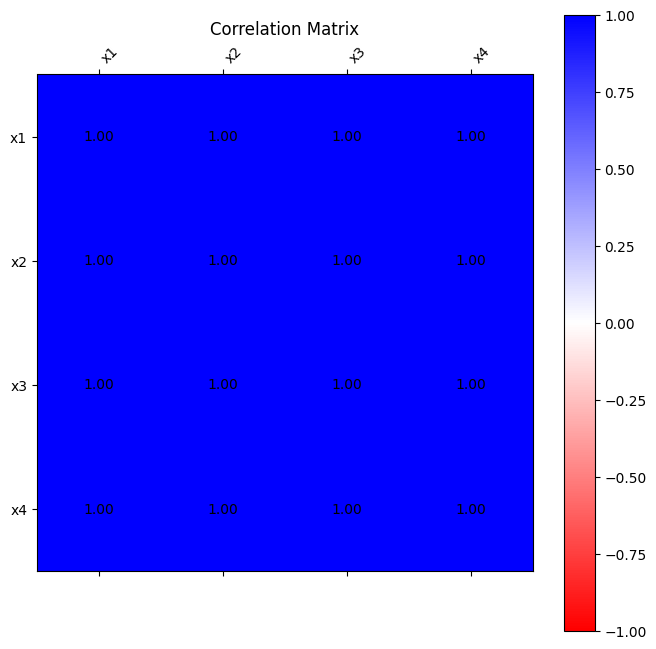

In [4]:
import matplotlib.colors as mcolors

# Create a custom diverging colormap where 0 is explicitly white
cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_coolwarm", ["red", "white", "blue"], N=256
)

# Create a plot to visualize the correlation matrix with white for zero
fig, ax = plt.subplots(figsize=(8, 8))

# Apply the custom colormap to the heatmap
cax = ax.matshow(corr_matrix, cmap=cmap, vmin=-1, vmax=1)

# Add color bar to the side
plt.colorbar(cax)

# Set the ticks for the x and y axis
ax.set_xticks(range(len(quantitative_vars)))
ax.set_yticks(range(len(quantitative_vars)))

# Set the labels for the ticks
ax.set_xticklabels(quantitative_vars, rotation=45, ha="left")
ax.set_yticklabels(quantitative_vars)

# Annotate the correlation matrix with the numeric values
for (i, j), val in np.ndenumerate(corr_matrix):
    ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="black")

# Display the plot
plt.title("Correlation Matrix")
plt.show()

In [5]:
model_full = ols("y ~ x1 + x2 + x3 + x4", data=mc_df).fit()
model_full.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 7.200e+04
Date:                Wed, 24 Sep 2025   Prob (F-statistic):          8.92e-308
Time:                        14:16:11   Log-Likelihood:                -515.82
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     195   BIC:                             1058.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.0374      0.462      2.248      0.026       0.127       1.948
x1            -0.1675      0.204     -0.821      0.413      -0.570       0.235
x2             1.1364      0.281      4.050      0.000       0.583       1.690
x3             0.9788      0.256      3.830      0.000       0.475       1.483
x4             1.1175      0.210      5.311      0.000       0.703       1.533
==============================================================================
Omnibus:                        0.460   Durbin-Watson:                   2.103
Prob(Omnibus):                  0.795   Jarque-Bera (JB):                0.219
Skew:                          -0.046   Prob(JB):                        0.896
Kurtosis:                       3.133   Cond. No.                         377.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [6]:
modelx1 = ols("y ~ x1", data=mc_df).fit()
modelx1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.396e+05
Date:                Wed, 24 Sep 2025   Prob (F-statistic):          5.39e-284
Time:                        14:16:11   Log-Likelihood:                -589.73
No. Observations:                 200   AIC:                             1183.
Df Residuals:                     198   BIC:                             1190.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.7257      0.659      2.617      0.010       0.426       3.026
x1             2.1250      0.006    373.575      0.000       2.114       2.136
==============================================================================
Omnibus:                        0.666   Durbin-Watson:                   2.009
Prob(Omnibus):                  0.717   Jarque-Bera (JB):                0.451
Skew:                          -0.106   Prob(JB):                        0.798
Kurtosis:                       3.095   Cond. No.                         233.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [7]:
modelx2 = ols("y ~ x2", data=mc_df).fit()
modelx2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.980e+05
Date:                Wed, 24 Sep 2025   Prob (F-statistic):          5.20e-299
Time:                        14:16:11   Log-Likelihood:                -554.80
No. Observations:                 200   AIC:                             1114.
Df Residuals:                     198   BIC:                             1120.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.3706      0.554      2.473      0.014       0.278       2.464
x2             2.3613      0.005    444.944      0.000       2.351       2.372
==============================================================================
Omnibus:                        0.045   Durbin-Watson:                   1.978
Prob(Omnibus):                  0.978   Jarque-Bera (JB):                0.043
Skew:                           0.030   Prob(JB):                        0.979
Kurtosis:                       2.960   Cond. No.                         210.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [8]:
modelx3 = ols("y ~ x3", data=mc_df).fit()
modelx3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 2.218e+05
Date:                Wed, 24 Sep 2025   Prob (F-statistic):          6.86e-304
Time:                        14:16:11   Log-Likelihood:                -543.45
No. Observations:                 200   AIC:                             1091.
Df Residuals:                     198   BIC:                             1098.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.0831      0.524      2.066      0.040       0.049       2.117
x3             2.9492      0.006    470.945      0.000       2.937       2.962
==============================================================================
Omnibus:                        0.792   Durbin-Watson:                   2.128
Prob(Omnibus):                  0.673   Jarque-Bera (JB):                0.741
Skew:                          -0.148   Prob(JB):                        0.690
Kurtosis:                       2.965   Cond. No.                         169.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [9]:
modelx4 = ols("y ~ x4", data=mc_df).fit()
modelx4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 1.307e+05
Date:                Wed, 24 Sep 2025   Prob (F-statistic):          3.46e-281
Time:                        14:16:11   Log-Likelihood:                -596.26
No. Observations:                 200   AIC:                             1197.
Df Residuals:                     198   BIC:                             1203.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.8964      0.683      1.312      0.191      -0.451       2.244
x4             4.2002      0.012    361.558      0.000       4.177       4.223
==============================================================================
Omnibus:                        0.500   Durbin-Watson:                   2.234
Prob(Omnibus):                  0.779   Jarque-Bera (JB):                0.641
Skew:                           0.079   Prob(JB):                        0.726
Kurtosis:                       2.772   Cond. No.                         119.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [10]:
# with the help of chatgpt, making it easer to compare the values.
models = {
    "full": model_full,
    "x1": modelx1,
    "x2": modelx2,
    "x3": modelx3,
    "x4": modelx4,
}

coef_se = pd.concat(
    {
        name: pd.DataFrame(
            {
                "coef": mod.params,
                "std_err": mod.bse,
            }
        )
        for name, mod in models.items()
    },
    names=["model", "term"],
).reset_index()

coef_se

,model,term,coef,std_err
0,full,Intercept,1.037358,0.461542
1,full,x1,-0.167540,0.204055
2,full,x2,1.136449,0.280617
3,full,x3,0.978820,0.255575
4,full,x4,1.117531,0.210430
5,x1,Intercept,1.725665,0.659300
6,x1,x1,2.124962,0.005688
7,x2,Intercept,1.370597,0.554270
8,x2,x2,2.361322,0.005307
9,x3,Intercept,1.083137,0.524205


There seems to be a significant presence of multicollinearity because for all predictors, we see the coef term change noticeably in magnitude with large std_err in the full model, compared to the singular models. 

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices  # an alternative to basic pandas dfs.

y, X = dmatrices("y ~ x1 + x2 + x3 + x4", data=mc_df, return_type="dataframe")

vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
print(vif)

    VIF Factor   features
0     4.080806  Intercept
1  2653.868613         x1
2  4066.198003         x2
3  2162.458352         x3
4   722.288919         x4


All the VIFs are concerning because they are all much larger than 10, which generally is the rule of thumb for "severe" multicollinearity. 

In [12]:
modelx4 = ols("x4 ~ x1 + x2 + x3", data=mc_df).fit()
modelx4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     x4   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.712e+04
Date:                Wed, 24 Sep 2025   Prob (F-statistic):          7.87e-280
Time:                        14:16:11   Log-Likelihood:                -300.24
No. Observations:                 200   AIC:                             608.5
Df Residuals:                     196   BIC:                             621.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0994      0.157      0.635      0.526      -0.209       0.408
x1             0.0078      0.069      0.112      0.911      -0.129       0.144
x2             0.0225      0.095      0.236      0.814      -0.165       0.210
x3             0.6626      0.073      9.113      0.000       0.519       0.806
==============================================================================
Omnibus:                        2.404   Durbin-Watson:                   2.129
Prob(Omnibus):                  0.301   Jarque-Bera (JB):                1.800
Skew:                          -0.004   Prob(JB):                        0.407
Kurtosis:                       2.535   Cond. No.                         358.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [13]:
res4 = modelx4.resid
res4

0     -0.089034
1      1.792657
2      0.724258
3      0.727658
4      0.033488
         ...   
195   -1.007361
196   -0.034044
197   -1.243194
198   -2.572986
199    1.140979
Length: 200, dtype: float64

In [14]:
modelres4 = ols("y ~ res4", data=mc_df).fit()
modelres4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                   0.01938
Date:                Wed, 24 Sep 2025   Prob (F-statistic):              0.889
Time:                        14:16:11   Log-Likelihood:                -1245.7
No. Observations:                 200   AIC:                             2495.
Df Residuals:                     198   BIC:                             2502.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    215.3599      8.716     24.707      0.000     198.171     232.549
res4           1.1175      8.028      0.139      0.889     -14.714      16.949
==============================================================================
Omnibus:                       91.438   Durbin-Watson:                   0.003
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               11.967
Skew:                          -0.004   Prob(JB):                      0.00252
Kurtosis:                       1.802   Cond. No.                         1.09
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

We notice that in part 4 the coefficient of Y ~ res4 of 1.1175 is the same as the coefficient of x4 from the full regression model in part 2. By residualizing x4, we are removing the variation explained by x1 to x3, thus the unique components of x4 only remain. 

Then regressing Y on this unique segment of res4 gives exactly the same partial effect of x4 on the full model regression. 

Geometrically, we are projecting x4 onto a subspace that is orthogonal to x1 to x3 and then projecting y onto that. 

We are not suprised because this is how the regression mechanically isolates the contributions of each predictor. 